# 01 — Exploratory Data Analysis
**Project:** Air Quality Forecasting — Aarhus PM2.5  
**Data source:** EEA Air Quality Download Service  

This notebook has three decisions:
1. **Data quality** — how much is missing / dirty, and what preprocessing is required?
2. **Station selection** — if multiple stations exist, which to use (or whether to aggregate)?
3. **Model selection** — what do the data patterns tell us about which model(s) to try?


Each section ends with a **Decision** block that outlines choices based on the findnings.

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

DATA_PATH = Path("../data/raw/eea/DK_PM25.csv")

---
## 1. Data Description
### 1.1 Load & first look

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['start', 'end'])
df = df.set_index("start").sort_index()

print(f"Shape:         {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range:    {df.index.min()} → {df.index.max()}")
print(f"Span:          {(df.index.max() - df.index.min()).days} days")
print()
df.head(10)

Shape:         110,211 rows × 7 columns
Date range:    2013-01-02 00:00:00+00:00 → 2026-05-08 20:00:00+00:00
Span:          4874 days



,station_id,end,value,unit,agg_type,validity,verification
start,,,,,,,
2013-01-02 00:00:00+00:00,DK/SPO-DK0034A_06001_100,2013-01-02 01:00:00+00:00,8.50,ug.m-3,hour,1,1
2013-01-02 01:00:00+00:00,DK/SPO-DK0034A_06001_100,2013-01-02 02:00:00+00:00,9.25,ug.m-3,hour,1,1
2013-01-02 02:00:00+00:00,DK/SPO-DK0034A_06001_100,2013-01-02 03:00:00+00:00,7.10,ug.m-3,hour,1,1
2013-01-02 03:00:00+00:00,DK/SPO-DK0034A_06001_100,2013-01-02 04:00:00+00:00,7.65,ug.m-3,hour,1,1
2013-01-02 04:00:00+00:00,DK/SPO-DK0034A_06001_100,2013-01-02 05:00:00+00:00,10.10,ug.m-3,hour,1,1
2013-01-02 05:00:00+00:00,DK/SPO-DK0034A_06001_100,2013-01-02 06:00:00+00:00,10.40,ug.m-3,hour,1,1
2013-01-02 06:00:00+00:00,DK/SPO-DK0034A_06001_100,2013-01-02 07:00:00+00:00,11.70,ug.m-3,hour,1,1
2013-01-02 07:00:00+00:00,DK/SPO-DK0034A_06001_100,2013-01-02 08:00:00+00:00,12.65,ug.m-3,hour,1,1
2013-01-02 08:00:00+00:00,DK/SPO-DK0034A_06001_100,2013-01-02 09:00:00+00:00,14.75,ug.m-3,hour,1,1


### 1.2 Data types

In [3]:
type_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null_count": df.count(),
    "null_count": df.isna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
    "sample_value": df.iloc[0],
})
type_summary

,dtype,non_null_count,null_count,null_pct,unique_values,sample_value
station_id,str,110211,0,0.0,2,DK/SPO-DK0034A_06001_100
end,"datetime64[us, UTC]",110211,0,0.0,110211,2013-01-02 01:00:00+00:00
value,float64,110211,0,0.0,1163,8.5
unit,str,110211,0,0.0,1,ug.m-3
agg_type,str,110211,0,0.0,1,hour
validity,int64,110211,0,0.0,3,1
verification,int64,110211,0,0.0,2,1


### 1.3 Descriptive statistics

In [4]:
df.describe().round(2)

,value,validity,verification
count,110211.00,110211.00,110211.0
mean,15.16,0.83,1.1
std,242.38,0.59,0.3
min,-1.95,-1.00,1.0
25%,5.55,1.00,1.0
50%,8.25,1.00,1.0
75%,11.70,1.00,1.0
max,9985.00,2.00,2.0


### 1.4 Station coverage

Before analysing missingness globally, check how many stations are in the data.
Multiple stations may have very different coverage and data quality, which affects
whether we should use all of them, aggregate them, or pick the best one.

In [5]:
station_summary = (
    df.groupby("station_id")["value"]
    .agg(
        count="count",
        first_obs=lambda s: s.index.min(),
        last_obs=lambda s: s.index.max(),
        mean="mean",
        missing_pct=lambda s: s.isna().mean() * 100,
    )
    .sort_values("count", ascending=False)
)

station_summary

,count,first_obs,last_obs,mean,missing_pct
station_id,,,,,
DK/SPO-DK0034A_06001_100,90268,2013-01-02 00:00:00+00:00,2023-12-04 11:00:00+00:00,9.091633,0.0
DK/SPO-DK0034A_06001_104,19943,2024-01-01 00:00:00+00:00,2026-05-08 20:00:00+00:00,42.637848,0.0


> **Decisions — station selection:**  
>- Looking at the metadata the two station ids are actually located at the exact same latitute/longitude. Thus, I keep both.
>- There is a gap between the last of the first and the beginning of the next. The gap is from 2023-12-04 12:00 -> 2023-12-31. This I will consider whether can be handled or whether the data can be found elsewhere. 

### 1.5 Missing values — when do they occur?

We distinguish three patterns of missingness because they call for different responses:
- **Random / sporadic** (isolated hours) → forward-fill or linear interpolation is safe.
- **Block gaps** (hours to days) → imputation introduces artificial autocorrelation; consider dropping those days entirely.
- **Seasonal / systematic** (specific hours or months missing consistently) → sensor issue; note the bias and flag it.

In [6]:
# Keeping all stations
# Continue with outliers we saw above to get a full picure
df_single = df.copy()

In [7]:
df_single = df_single[df_single.index.year >= 2015].copy()
full_range = pd.date_range(start=df_single.index.min(), end=df_single.index.max(), freq="h")
df_full = df_single.reindex(full_range)

missing_mask = df_full["value"].isna()
n_missing    = missing_mask.sum()
pct_missing  = missing_mask.mean() * 100

print(f"Expected hourly observations: {len(full_range):,}")
print(f"Actual observations:          {len(df_single):,}")
print(f"Missing hours:                {n_missing:,} ({pct_missing:.1f}%)")

# Consecutive missing streaks
missing_streaks = (
    missing_mask.astype(int)
    .groupby((missing_mask != missing_mask.shift()).cumsum())
    .agg(["sum", "first"])
)
missing_streaks = missing_streaks[missing_streaks["first"] == 1].rename(columns={"sum": "streak_length_hours"})
print(f"\nLongest gap:    {missing_streaks['streak_length_hours'].max()} hours")
print(f"Gaps > 24h:     {(missing_streaks['streak_length_hours'] > 24).sum()}")
print(f"Gaps > 1 week:  {(missing_streaks['streak_length_hours'] > 168).sum()}")
print()
print("Streak length distribution (hours):")
print(missing_streaks["streak_length_hours"].describe().round(1))

Expected hourly observations: 99,501
Actual observations:          98,171
Missing hours:                1,330 (1.3%)

Longest gap:    660 hours
Gaps > 24h:     3
Gaps > 1 week:  2

Streak length distribution (hours):
count      6.0
mean     221.7
std      329.4
min        1.0
25%        1.5
50%       17.5
75%      482.8
max      660.0
Name: streak_length_hours, dtype: float64


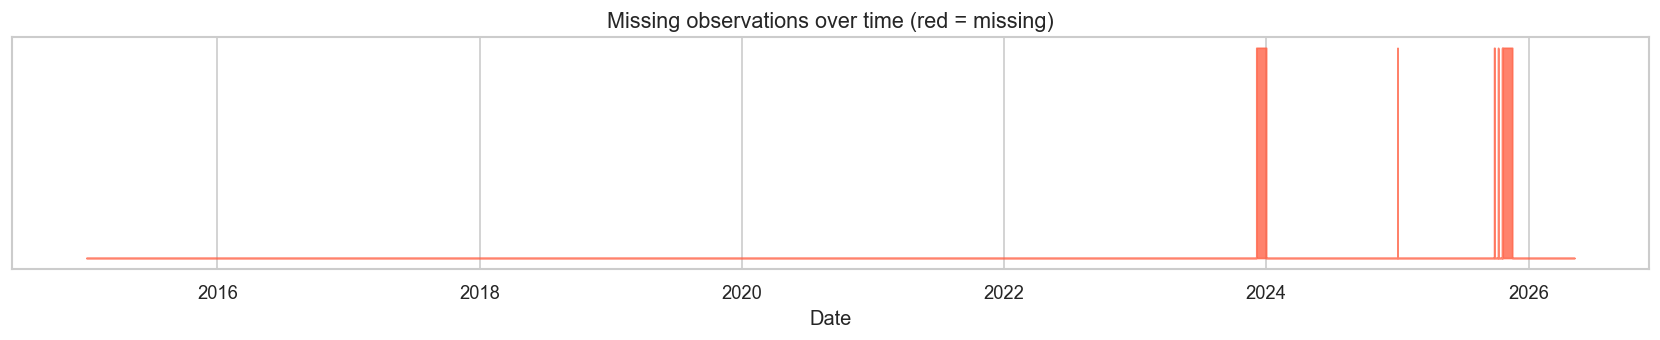

In [8]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(df_full.index, missing_mask.astype(int), step="mid", color="tomato", alpha=0.8)
ax.set_title("Missing observations over time (red = missing)", fontsize=13)
ax.set_xlabel("Date")
ax.set_yticks([])
plt.tight_layout()
plt.show()

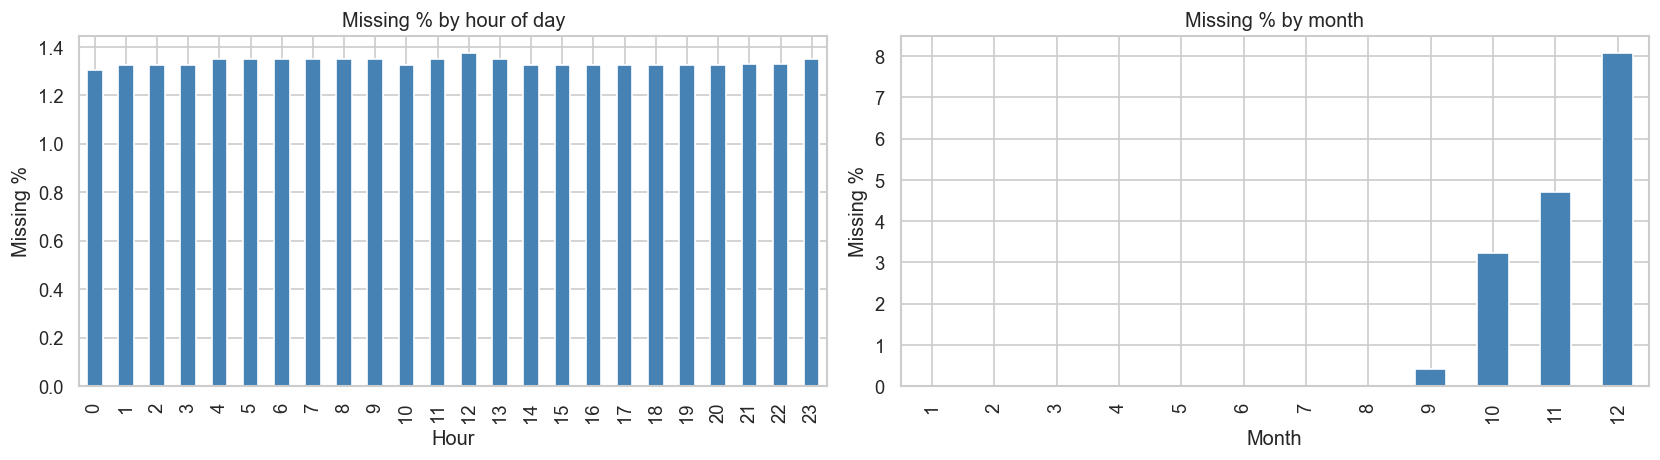

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

missing_by_hour  = df_full["value"].isna().groupby(df_full.index.hour).mean() * 100
missing_by_month = df_full["value"].isna().groupby(df_full.index.month).mean() * 100

missing_by_hour.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Missing % by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Missing %")

missing_by_month.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Missing % by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Missing %")

plt.tight_layout()
plt.show()

> **Decisions — missing data strategy:**  
> - The missing data in December 2023 is a much too large gap. Check whether data is available elsewhere
> - November in 2025 is also missing way too much data (50%). Check whether this is available anywhere too. 

### 1.6 Outlier detection

PM2.5 outliers can be genuine pollution events (e.g. Saharan dust, fireworks) or sensor artefacts.
Distinguishing them matters: genuine events should be kept in the training data because the model
needs to learn them; sensor errors should be removed. The main heuristics are:
- **Negative values** → always sensor errors; remove.
- **Isolated spikes** (value >> neighbours) → likely sensor artefacts.
- **Sustained elevated periods** (multi-day) → likely real pollution events; keep.

First, I'll look into values that are not physically plausible.

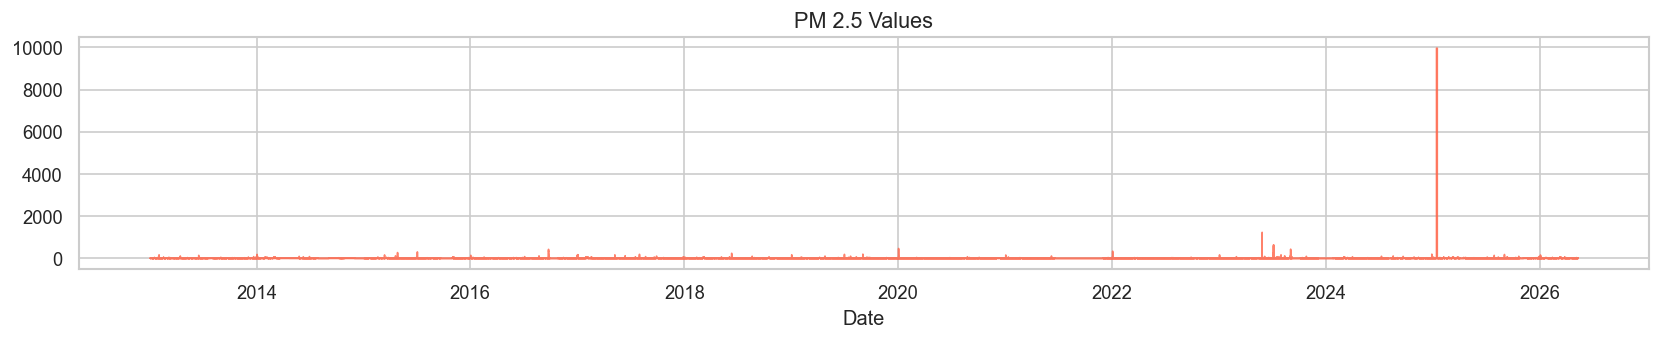

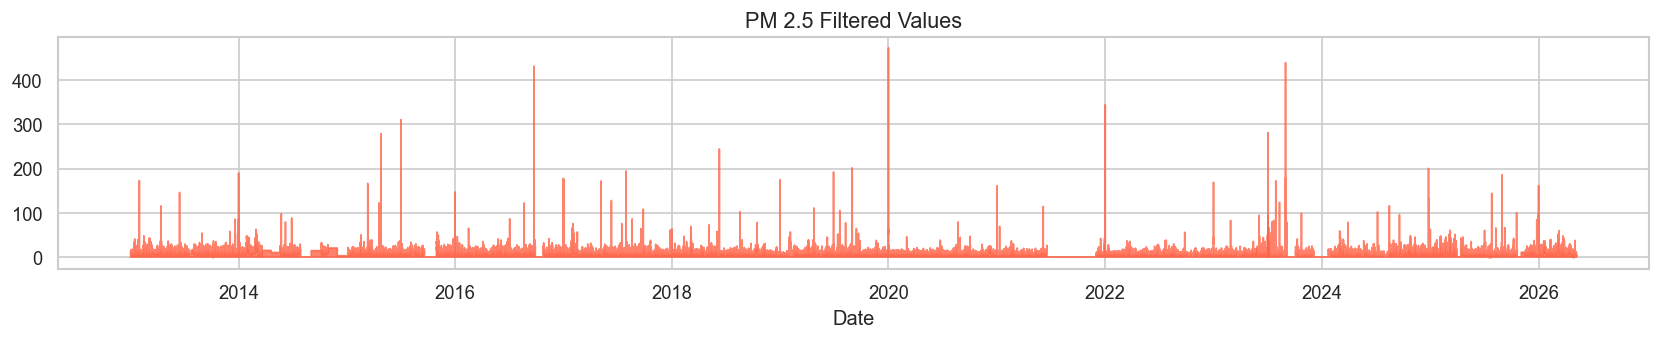

,start_date,end_date,length
value,,,
65496,2021-06-18 10:00:00+00:00,2021-11-30 12:00:00+00:00,3963
18065,2015-09-19 06:00:00+00:00,2015-10-29 19:00:00+00:00,974
79810,2023-09-05 09:00:00+00:00,2023-10-04 20:00:00+00:00,708
25799,2016-09-27 09:00:00+00:00,2016-10-23 22:00:00+00:00,638
81156,2023-12-04 10:00:00+00:00,2024-01-23 08:00:00+00:00,539
...,...,...,...
65654,2021-12-07 07:00:00+00:00,2021-12-07 11:00:00+00:00,5
82675,2024-04-03 00:00:00+00:00,2024-04-03 04:00:00+00:00,5
79821,2023-10-05 07:00:00+00:00,2023-10-05 11:00:00+00:00,5


In [10]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(df.index, df['value'], step="mid", color="tomato", alpha=0.8)
ax.set_title("PM 2.5 Values", fontsize=13)
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

# One extreme outlier of 9985.00 which must be an error + a couple of other high values; set temporarily to NaN
df_filtered = df.copy()
df_filtered.loc[df_filtered["value"] >= 500, "value"] = np.nan
fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(df_filtered.index, df_filtered['value'], step="mid", color="tomato", alpha=0.8)
ax.set_title("PM 2.5 Filtered Values", fontsize=13)
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()


# It seems like there are a  couple of long stretches with data being 0
# I'll see how long and how many of these there are
zero_stretches = (df_filtered["value"] == 0).astype(int).groupby((df_filtered["value"] != 0).cumsum()).agg(
    start_date=lambda s: s.index.min(),
    end_date=lambda s: s.index.max(),
    length="size"
)
zero_stretches = zero_stretches[zero_stretches["length"] >= 5]  # Only keep stretches of 5+ hours
zero_stretches.sort_values("length", ascending=False)


In [11]:
# The longest stretch of 0 values is 3963/24 hours (165.125 days)
3963
# There are 14 days that have longer stretches than 100 hours i.e. more than 4 days of continuous 0 values
zero_stretches.sort_values("length", ascending=False).head(15)

# To test whether these are correct and not faulty one could check the data against values from nearby stations
# For the sake of this project I will assume that that they are correct since they are spread throughout the dataset

,start_date,end_date,length
value,,,
65496,2021-06-18 10:00:00+00:00,2021-11-30 12:00:00+00:00,3963
18065,2015-09-19 06:00:00+00:00,2015-10-29 19:00:00+00:00,974
79810,2023-09-05 09:00:00+00:00,2023-10-04 20:00:00+00:00,708
25799,2016-09-27 09:00:00+00:00,2016-10-23 22:00:00+00:00,638
81156,2023-12-04 10:00:00+00:00,2024-01-23 08:00:00+00:00,539
90880,2025-03-31 22:00:00+00:00,2025-04-13 14:00:00+00:00,305
85334,2024-07-30 08:00:00+00:00,2024-08-09 06:00:00+00:00,239
72603,2022-10-06 09:00:00+00:00,2022-10-13 15:00:00+00:00,175
81165,2024-01-23 17:00:00+00:00,2024-01-30 14:00:00+00:00,166


##### Now to the outliers

In [12]:
pm25 = df_single["value"].dropna()

q01  = pm25.quantile(0.01)
q99  = pm25.quantile(0.99)
iqr  = pm25.quantile(0.75) - pm25.quantile(0.25)
iqr_upper = pm25.quantile(0.75) + 3 * iqr   # 3×IQR is conservative for right-skewed data

n_negative  = (pm25 < 0).sum()
n_iqr_spike = (pm25 > iqr_upper).sum()
n_p99_spike = (pm25 > q99).sum()

print(f"Negative values (sensor errors):          {n_negative}")
print(f"Above 3×IQR fence ({iqr_upper:.1f} µg/m³):        {n_iqr_spike}")
print(f"Above 99th percentile ({q99:.1f} µg/m³):       {n_p99_spike}")
print(f"Min: {pm25.min():.2f}  Max: {pm25.max():.2f}  Mean: {pm25.mean():.2f}  Median: {pm25.median():.2f}")

skewness = pm25.skew()
print(f"\nSkewness: {skewness:.2f} — {'right-skewed (long tail of high-pollution events)' if skewness > 1 else 'approximately symmetric'}")
print()
print("Skewness > 1 suggests a log-transform of the target may stabilise variance.")
print("Re-evaluate after seeing the lag scatter plots in Section 3.4.")

Negative values (sensor errors):          27
Above 3×IQR fence (28.9 µg/m³):        1409
Above 99th percentile (32.5 µg/m³):       977
Min: -1.90  Max: 9985.00  Mean: 15.47  Median: 7.90

Skewness: 38.75 — right-skewed (long tail of high-pollution events)

Skewness > 1 suggests a log-transform of the target may stabilise variance.
Re-evaluate after seeing the lag scatter plots in Section 3.4.


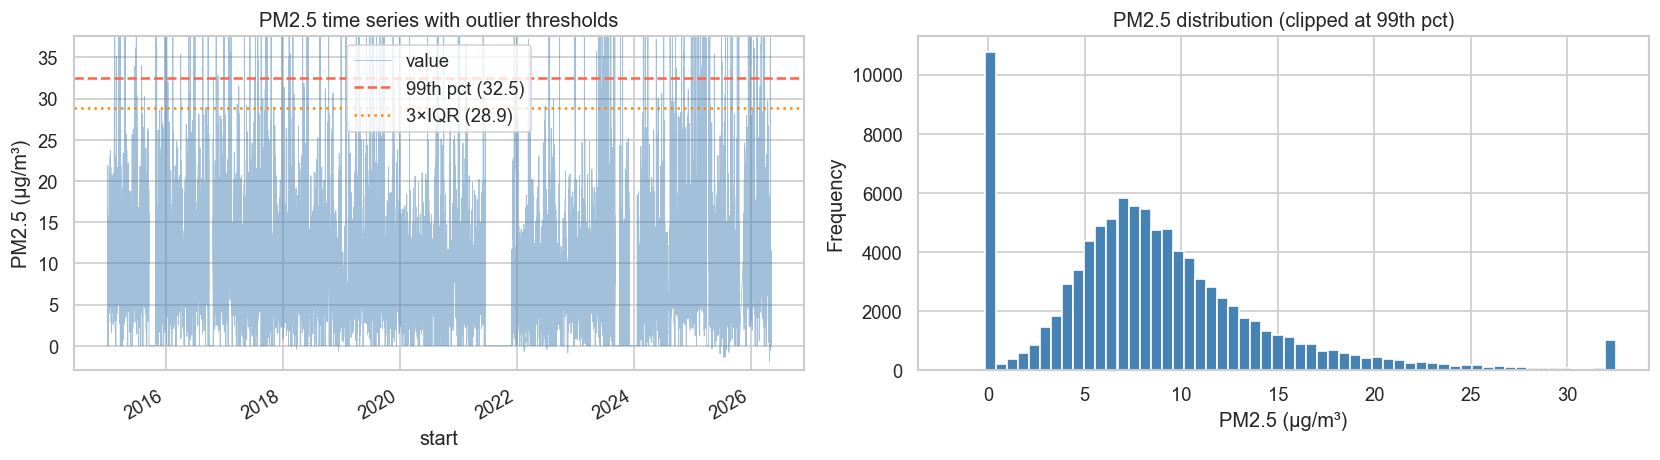

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pm25.plot(ax=axes[0], alpha=0.5, linewidth=0.5, color="steelblue")
axes[0].axhline(q99,       color="tomato",    linestyle="--", label=f"99th pct ({q99:.1f})")
axes[0].axhline(iqr_upper, color="darkorange", linestyle=":",  label=f"3×IQR ({iqr_upper:.1f})")
axes[0].set_title("PM2.5 time series with outlier thresholds")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].set_ylim(bottom=-3, top=iqr_upper * 1.3)  # ← zoom in; outliers still visible as threshold lines
axes[0].legend()

pm25.clip(upper=q99).plot.hist(bins=60, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("PM2.5 distribution (clipped at 99th pct)")
axes[1].set_xlabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

> **Decisions — outlier handling:**  
> - Negative values are not possible i.e. Remove them.  
> - For large spikes: one could check whether the spike is isolated (single hour, no elevated neighbours). If isolated, cap or remove. If part of a multi-hour elevated period, keep it — it's likely real. For this proect - base on the plot of the filtered data - I will remove any value above 300 as these looks to be singular hours. 
> - As skewness > 1.5, consider log-transforming the target. Check this again after the lag scatter plots (Section 2.6). A log transform is only worthwhile if it substantially linearises the lag relationship.

---
## 2. Model Selection Analysis

We examine six things to inform which model(s) to build:

1. **Persistence baseline** — concrete benchmark any model must beat
2. **Long-term trend** — is the series drifting? (affects stationarity and training window)
3. **Seasonality** — weekly and annual patterns (informs time-based features)
4. **Autocorrelation** — how far back does memory extend? (informs lag features)
5. **Stationarity** — ADF test (informs whether linear models need differencing)
6. **Non-linearity** — lag scatter plots (informs whether tree-based models are needed)

### 2.1 Persistence baseline — the benchmark every model must beat

The simplest possible forecast is the **persistence model**: predict tomorrow = today.
Computing its MAE now gives a concrete floor — any model we build is only worth deploying
if it improves on this number on the held-out test set.

We check two variants:
- **Lag-1:** tomorrow's mean = today's mean
- **Lag-7:** tomorrow's mean = the same weekday last week (captures weekly seasonality)

In [14]:
df_single.loc[df_single["value"] >= 5000, "value"] = np.nan # Remove major outlier
daily_mean = df_single["value"].resample("D").mean()

persist_lag1_mae = (daily_mean - daily_mean.shift(1)).abs().mean()
persist_lag7_mae = (daily_mean - daily_mean.shift(7)).abs().mean()
naive_mae        = (daily_mean - daily_mean.mean()).abs().mean()

print("Persistence / naive baseline MAE (µg/m³) for tomorrow's daily mean PM2.5")
print()
print(f"  Lag-1 persistence (predict today's mean):        {persist_lag1_mae:.3f}")
print(f"  Lag-7 persistence (predict same weekday -1w):    {persist_lag7_mae:.3f}")
print(f"  Naive (always predict overall mean):             {naive_mae:.3f}")
print()
print("Any model that does not beat the lag-1 MAE on the test set provides no value.")

Persistence / naive baseline MAE (µg/m³) for tomorrow's daily mean PM2.5

  Lag-1 persistence (predict today's mean):        2.568
  Lag-7 persistence (predict same weekday -1w):    4.190
  Naive (always predict overall mean):             3.610

Any model that does not beat the lag-1 MAE on the test set provides no value.


### 2.2 Long-term trend & STL decomposition

Check whether PM2.5 is trending over the years.
A downward trend (cleaner air policy) means the series distribution is shifting,
which can cause a model trained on old data to systematically over-predict.
An upward trend is rare but would have the opposite effect.

STL (Seasonal-Trend decomposition using Loess) separates the series into:
- **Trend** — the slow-moving level
- **Seasonal** — repeating annual pattern
- **Residual** — what the model actually needs to learn

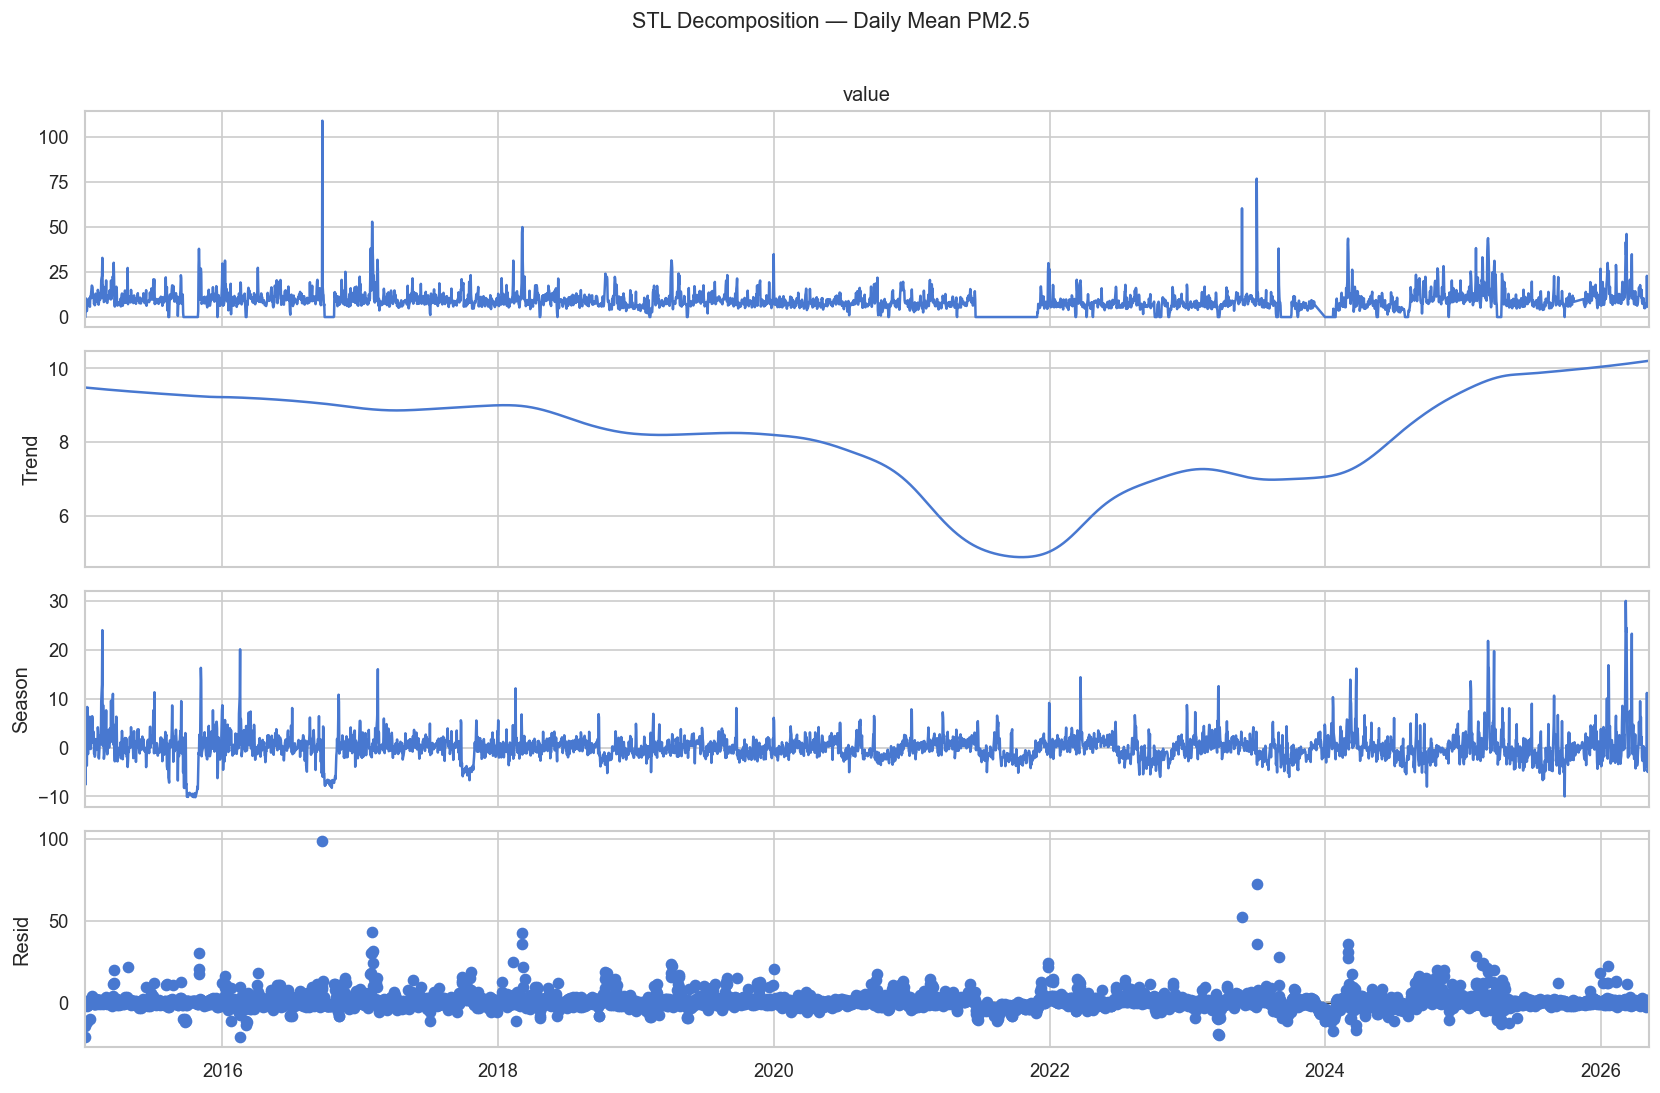

Trend range (max - min):  5.33 µg/m³
Trend slope:              -0.085 µg/m³ per year

Seasonal strength (variance of seasonal component / variance of (seasonal + residual)):
  0.26  (> 0.6 = strong seasonality, worth capturing as a feature)


In [15]:
# STL needs a regularly-spaced series without NaN — use daily means, interpolate gaps 
# We know there is a large gap in 2022 this should not have a major impact when interpolated
daily_filled = daily_mean.interpolate(method="linear").dropna()

# period=365 for annual seasonality on daily data
stl = STL(daily_filled, period=365, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(14, 9)
fig.suptitle("STL Decomposition — Daily Mean PM2.5", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Quantify trend magnitude
trend_range = res.trend.max() - res.trend.min()
trend_slope = np.polyfit(np.arange(len(res.trend)), res.trend, 1)[0]  # µg/m³ per day
print(f"Trend range (max - min):  {trend_range:.2f} µg/m³")
print(f"Trend slope:              {trend_slope * 365:.3f} µg/m³ per year")
print()
print("Seasonal strength (variance of seasonal component / variance of (seasonal + residual)):")
var_s   = res.seasonal.var()
var_r   = res.resid.var()
strength = max(0, 1 - var_r / (var_s + var_r))
print(f"  {strength:.2f}  (> 0.6 = strong seasonality, worth capturing as a feature)")

> **Decision guide — trend:**  
> - Trend slope < ±0.5 µg/m³/year → the distribution is not shifting meaningfully.
>   Thus, the full history can be used for training without adjustment.
> - Season Strength: 0.23 → weak seasonality. Lag features are more important than specific modeling of seasonality. Can add categorical feature of month and season but most likely wont add much predictive power. 

### 2.3 Seasonality — weekly and annual patterns

Even with weak annual seasonality (STL strength = 0.23), calendar patterns at
finer granularities can still exist. The weekly range checks for weekday/weekend
human-activity cycles that STL ignores entirely. The monthly range checks whether
the annual pattern is strong enough to justify adding `month` as a categorical
feature. If both ranges fall below the thresholds, skip both features — lag
and rolling-mean features will carry the model instead.

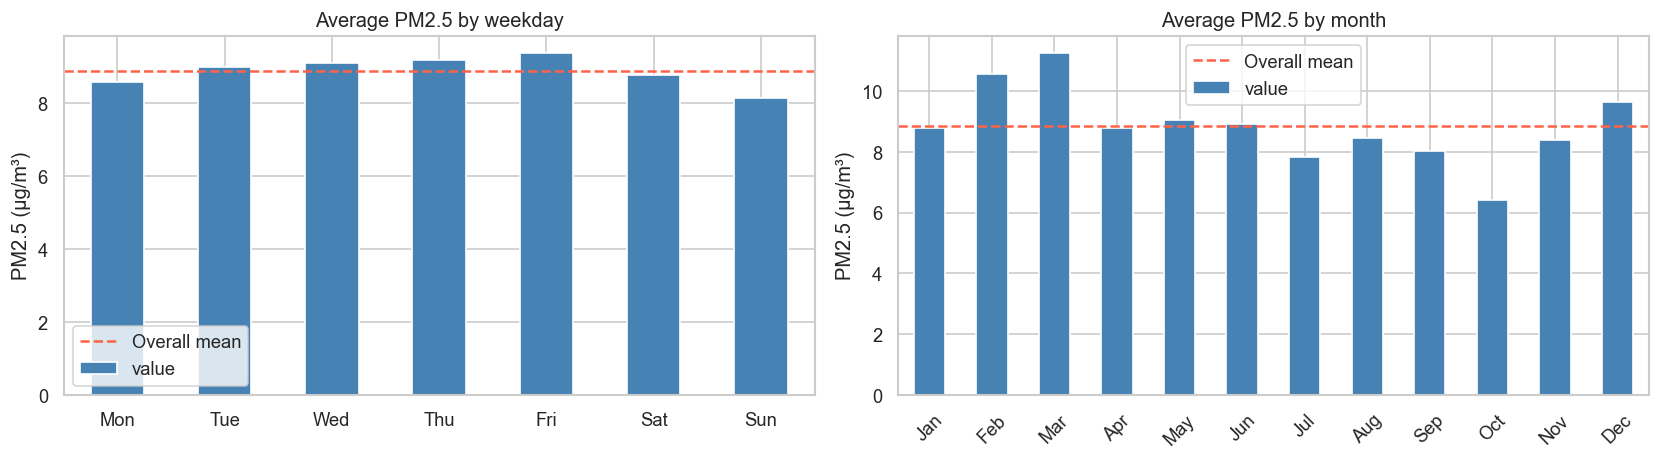

Weekly range:  9.36 - 8.12 = 1.24 µg/m³
Monthly range: 11.24 - 6.42 = 4.83 µg/m³

Rule of thumb:
  Monthly range > 3 µg/m³ → month is a meaningful feature.
  Weekly  range > 1 µg/m³ → weekday is a meaningful feature.
  These thresholds are relative to the overall mean — scale accordingly.


In [16]:
day_names   = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

weekly  = df_single["value"].groupby(df_single.index.dayofweek).mean()
monthly = df_single["value"].groupby(df_single.index.month).mean()
weekly.index  = day_names
monthly.index = month_names

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

weekly.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Average PM2.5 by weekday")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].tick_params(axis="x", rotation=0)
axes[0].axhline(weekly.mean(), color="tomato", linestyle="--", label="Overall mean")
axes[0].legend()

monthly.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Average PM2.5 by month")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(monthly.mean(), color="tomato", linestyle="--", label="Overall mean")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Weekly range:  {weekly.max():.2f} - {weekly.min():.2f} = {weekly.max()-weekly.min():.2f} µg/m³")
print(f"Monthly range: {monthly.max():.2f} - {monthly.min():.2f} = {monthly.max()-monthly.min():.2f} µg/m³")
print()
print("Rule of thumb:")
print("  Monthly range > 3 µg/m³ → month is a meaningful feature.")
print("  Weekly  range > 1 µg/m³ → weekday is a meaningful feature.")
print("  These thresholds are relative to the overall mean — scale accordingly.")

**Decision - seasonal features**
> - Add both monthly and weekly categorical features

### 2.4 Autocorrelation — how much does past PM2.5 predict future PM2.5?

The ACF and PACF together reveal the lag structure of the series:
- **ACF** shows the total correlation between today and each past day.
  A slowly-decaying ACF means the series has long memory.
- **PACF** shows the *direct* correlation at each lag after removing
  the effect of intermediate lags. Significant PACF spikes at lags k
  indicate that lag k should be included as a feature.

We also print lag-1 and lag-7 autocorrelations numerically — these
are the two most commonly useful features for daily PM2.5.

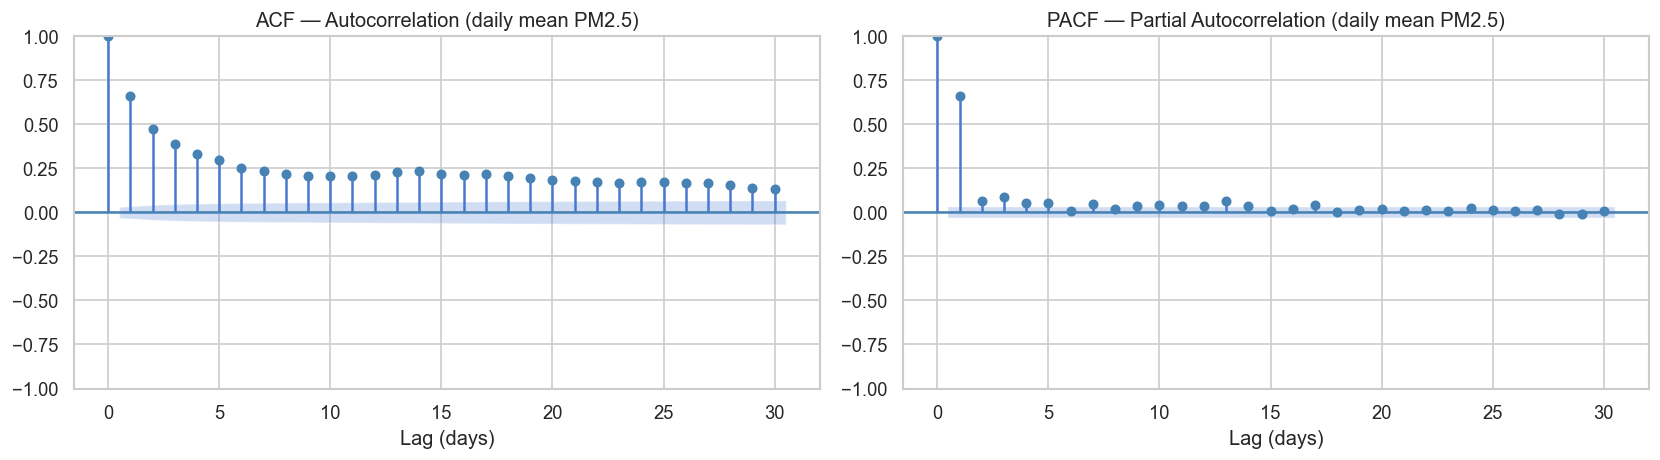

Autocorrelation by lag:
   lag_1: +0.661  ███████████████████
   lag_2: +0.474  ██████████████
   lag_3: +0.386  ███████████
   lag_7: +0.234  ███████
  lag_14: +0.234  ███████
  lag_30: +0.135  ████

Significant PACF lags (above the dashed confidence band) should be included as features.
As a rule: lag-1 almost always matters; lag-7 matters if there is a weekly cycle.


In [17]:
daily_clean = daily_mean.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( daily_clean, lags=30, ax=axes[0], color="steelblue")
axes[0].set_title("ACF — Autocorrelation (daily mean PM2.5)")
axes[0].set_xlabel("Lag (days)")

plot_pacf(daily_clean, lags=30, ax=axes[1], color="steelblue", method="ywm")
axes[1].set_title("PACF — Partial Autocorrelation (daily mean PM2.5)")
axes[1].set_xlabel("Lag (days)")

plt.tight_layout()
plt.show()

corrs = {f"lag_{k}": daily_clean.autocorr(lag=k) for k in [1, 2, 3, 7, 14, 30]}
print("Autocorrelation by lag:")
for k, c in corrs.items():
    bar = "█" * int(abs(c) * 30)
    print(f"  {k:>6}: {c:+.3f}  {bar}")
print()
print("Significant PACF lags (above the dashed confidence band) should be included as features.")
print("As a rule: lag-1 almost always matters; lag-7 matters if there is a weekly cycle.")

> **Decision — lag features:**  
> - Autocorr(lag-1) > 0.5 → `pm25_t-1` is a must-have feature.  
> - Autocorr(lag-7) > 0.2 → `pm25_t-7` is worth including; weekly cycle exists.  
> - PACF: Only lag one and two are significant. 
> - ACF: Is slowly decaying → Add a lag_14 feature alongside lag_1 and lag_7 — the weekly cycle persists two weeks out and is worth capturing.

### 2.5 Stationarity — Augmented Dickey-Fuller test

Stationarity means the statistical properties (mean, variance, autocorrelation)
do not change over time. The ADF test checks for a unit root to inform model choice:
- Linear models (ARIMA, Ridge) assume stationarity; non-stationary series need differencing first.
- Tree-based models (LightGBM) are more robust to non-stationarity because they
  operate on feature values rather than directly modelling the level.

In [18]:
adf_result = adfuller(daily_clean, autolag="AIC")

print("Augmented Dickey-Fuller test (null hypothesis: series has a unit root)")
print(f"  Test statistic: {adf_result[0]:.4f}")
print(f"  p-value:        {adf_result[1]:.4f}")
print(f"  Lags used:      {adf_result[2]}")
print(f"  Critical values:")
for key, val in adf_result[4].items():
    print(f"    {key}: {val:.4f}")
print()
if adf_result[1] < 0.05:
    print("✓ Stationary (p < 0.05) — unit root rejected.")
    print("  No differencing needed. All model types can be applied directly.")
else:
    print("✗ Non-stationary (p ≥ 0.05) — unit root not rejected.")
    print("  Linear models: first-difference the target before training (predict Δpm25 instead of pm25).")
    print("  Tree-based (LightGBM): can be applied without differencing, but adding a trend feature is recommended.")
    print("  Check Section 3.1 — if a clear trend is visible, removing it via STL may be enough.")

Augmented Dickey-Fuller test (null hypothesis: series has a unit root)
  Test statistic: -9.0329
  p-value:        0.0000
  Lags used:      16
  Critical values:
    1%: -3.4320
    5%: -2.8622
    10%: -2.5671

✓ Stationary (p < 0.05) — unit root rejected.
  No differencing needed. All model types can be applied directly.


**Decision - Stationarity**
> - Unit root rejected - The series is stationary: No differencing needed. 

### 2.6 Non-linearity — lag feature scatter plots

If the relationship between lag features and the target is linear,
a simple linear regression may perform nearly as well as LightGBM.
If it is non-linear (fan-shaped, curved, or clustered), tree-based
models will have a clear advantage.

A **fan shape** (variance grows with the lag value) also suggests that
log-transforming the target will help — it stabilises that heteroscedasticity.

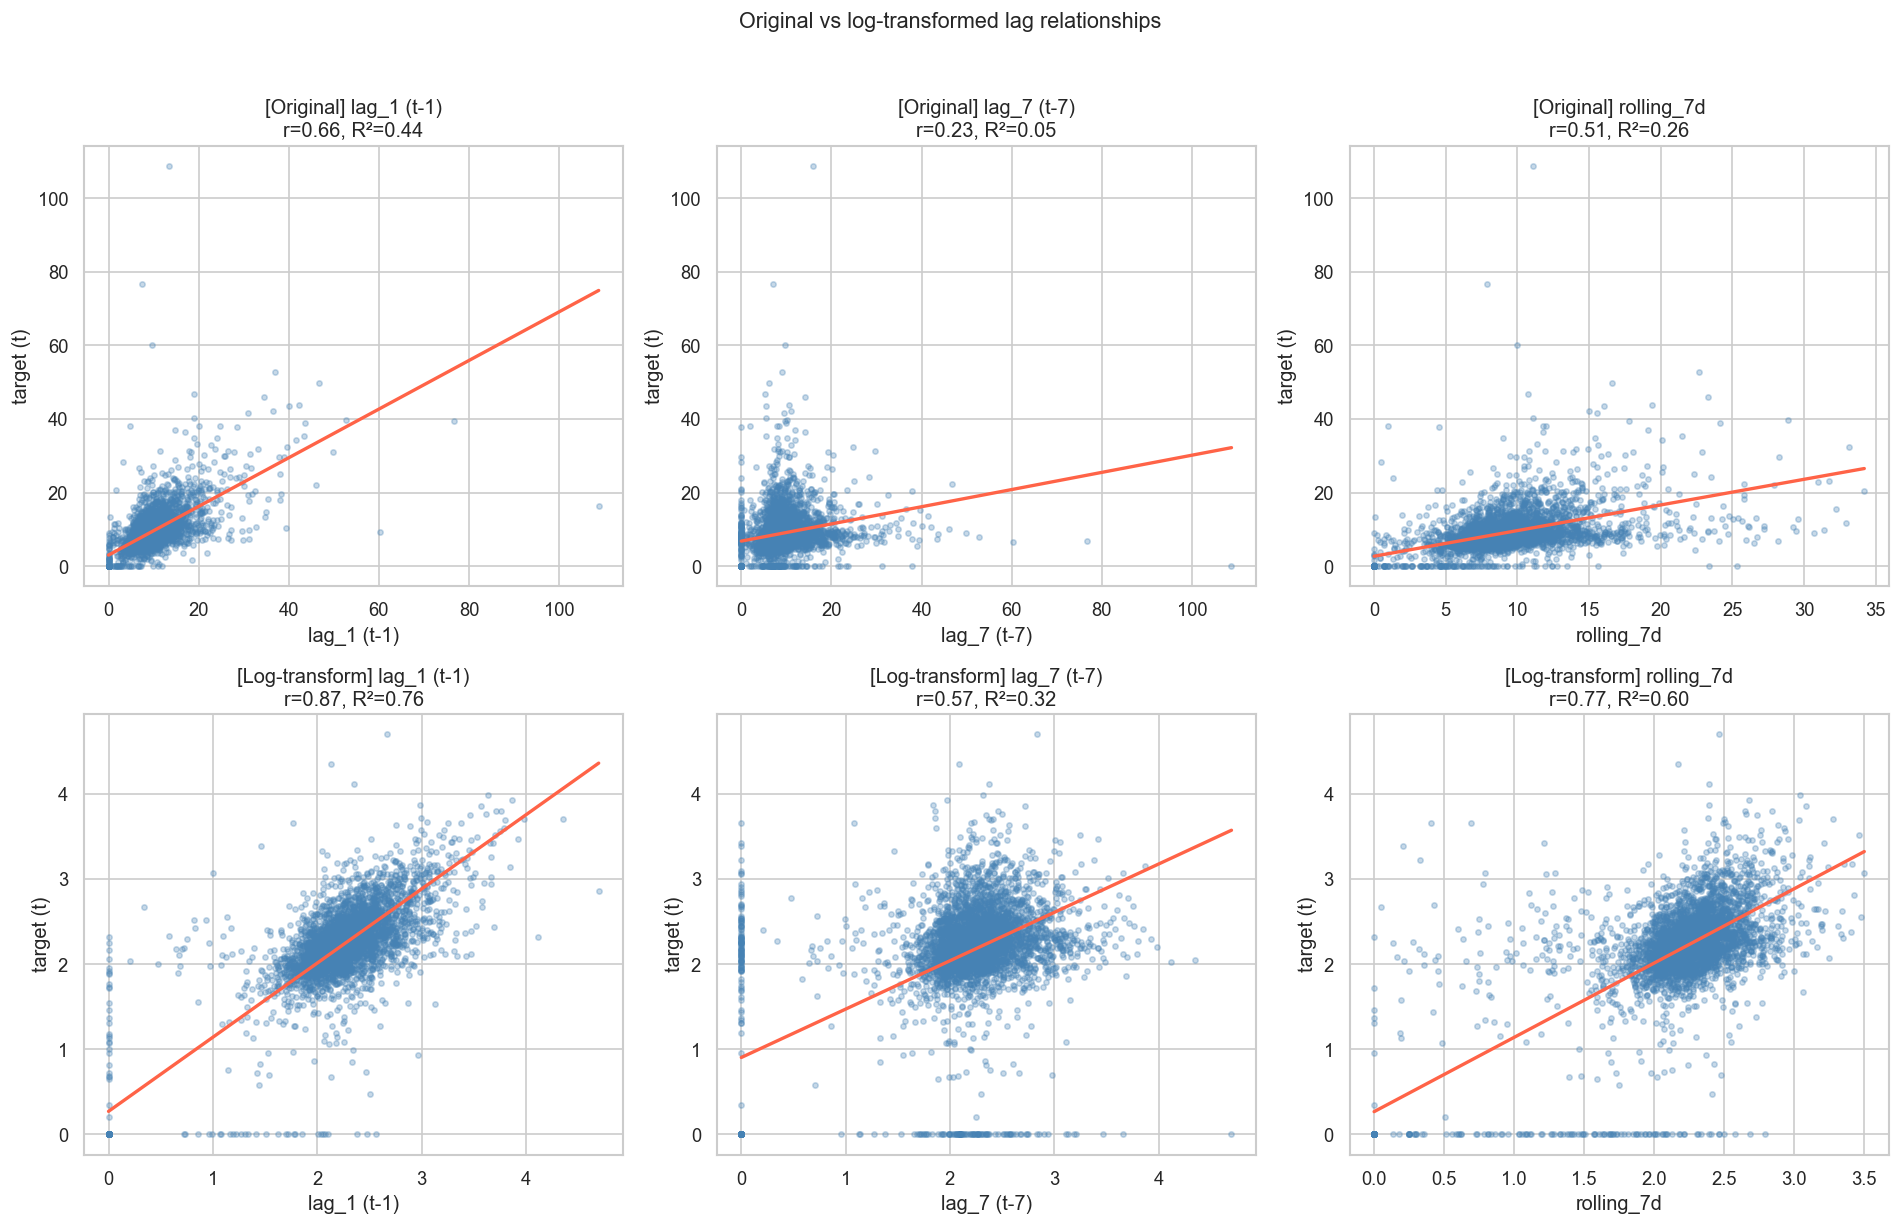

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row, (label, target) in enumerate([
    ("Original",      daily_clean),
    ("Log-transform", np.log1p(daily_clean)),  # log1p handles zeros safely
]):
    lag_df = pd.DataFrame({
        "target (t)":  target,
        "lag_1 (t-1)": target.shift(1),
        "lag_7 (t-7)": target.shift(7),
        "rolling_7d":  target.shift(1).rolling(7).mean(),
    }).dropna()

    for ax, col in zip(axes[row], ["lag_1 (t-1)", "lag_7 (t-7)", "rolling_7d"]):
        ax.scatter(lag_df[col], lag_df["target (t)"], alpha=0.3, s=10, color="steelblue")

        z = np.polyfit(lag_df[col], lag_df["target (t)"], 1)
        p = np.poly1d(z)
        x_line = np.linspace(lag_df[col].min(), lag_df[col].max(), 100)
        ax.plot(x_line, p(x_line), color="tomato", linewidth=2)

        corr  = lag_df[col].corr(lag_df["target (t)"])
        r_sq  = corr ** 2
        ax.set_title(f"[{label}] {col}\nr={corr:.2f}, R²={r_sq:.2f}")
        ax.set_xlabel(col)
        ax.set_ylabel("target (t)")

plt.suptitle("Original vs log-transformed lag relationships", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Decision - non-linearity**
> - Especially due to lag 1 and rolling mean o lag 7 the log transform should be applied to the target and features. 

### 2.7 Correlation matrix — feature candidates

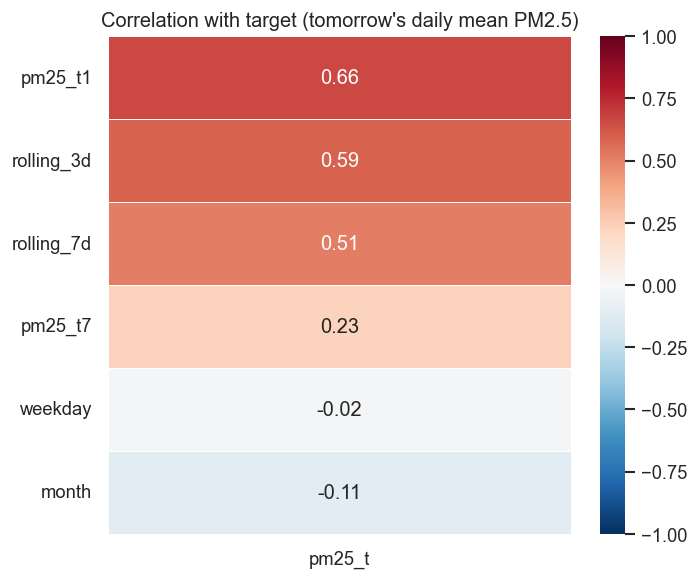

Feature correlation with target (ranked):
            pm25_t
pm25_t1      0.661
rolling_3d   0.592
rolling_7d   0.512
pm25_t7      0.234
weekday     -0.019
month       -0.112

Features with |r| < 0.05 contribute little in a linear model.
Even low-correlation features can help LightGBM via non-linear interactions.


In [22]:
feature_df = pd.DataFrame({
    "pm25_t":    daily_clean,
    "pm25_t1":   daily_clean.shift(1),
    "pm25_t7":   daily_clean.shift(7),
    "rolling_3d": daily_clean.shift(1).rolling(3).mean(),
    "rolling_7d": daily_clean.shift(1).rolling(7).mean(),
    "weekday":   daily_clean.index.dayofweek,
    "month":     daily_clean.index.month,
}).dropna()

corr_matrix = feature_df.corr()[["pm25_t"]].drop("pm25_t").sort_values("pm25_t", ascending=False)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
)
ax.set_title("Correlation with target (tomorrow's daily mean PM2.5)")
plt.tight_layout()
plt.show()

print("Feature correlation with target (ranked):")
print(corr_matrix.round(3).to_string())
print()
print("Features with |r| < 0.05 contribute little in a linear model.")
print("Even low-correlation features can help LightGBM via non-linear interactions.")

**Decision - feature selection**
> - All but weekday should contribute meaningfully to any chosen model. but weekday might add to GBM models predcition power. 

### 2.8 Train / validation / test split

For time series, the test set must always be the most recent data —
never sampled randomly. This section decides where to cut the data.

Training:    3388 days  (2015-01-01 → 2024-05-07)
Validation:   363 days  (2024-05-08 → 2025-05-07)
Test:         341 days  (2025-05-08 → 2026-05-08)

✓ Training set spans at least 2 annual cycles — sufficient for seasonal patterns.


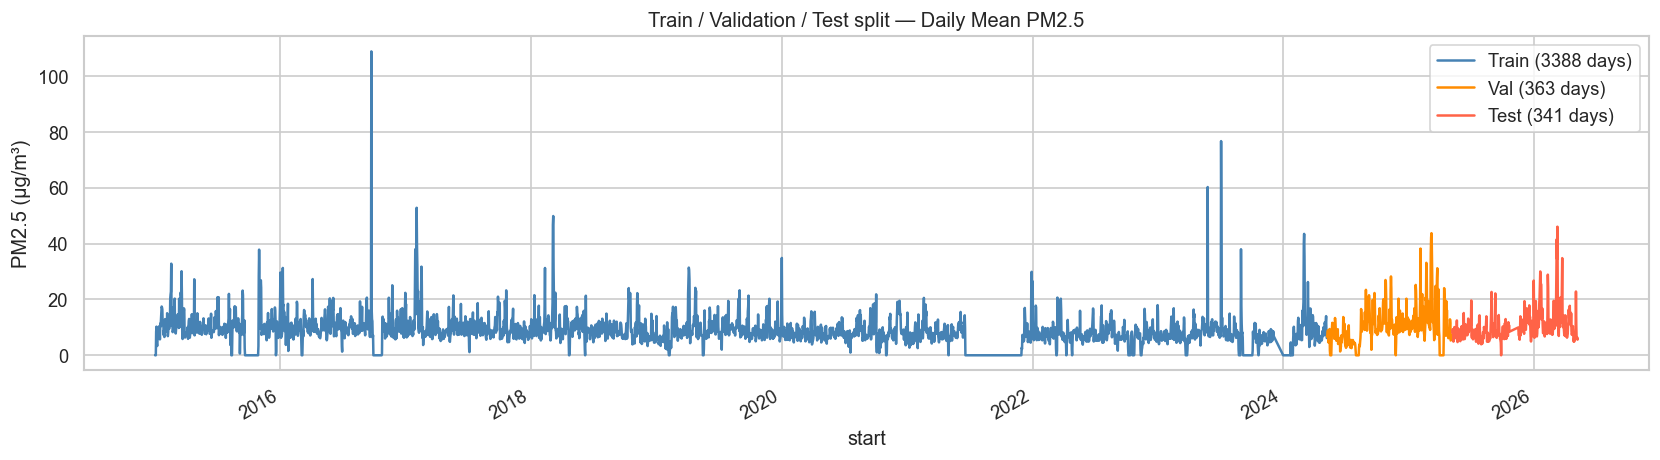

In [25]:
TEST_DAYS = 365
VAL_DAYS  = 365

cut_test = daily_clean.index.max() - pd.Timedelta(days=TEST_DAYS)
cut_val  = cut_test - pd.Timedelta(days=VAL_DAYS)

train = daily_clean[daily_clean.index < cut_val]
val   = daily_clean[(daily_clean.index >= cut_val) & (daily_clean.index < cut_test)]
test  = daily_clean[daily_clean.index >= cut_test]

print(f"Training:   {len(train):>5} days  ({train.index.min().date()} → {train.index.max().date()})")
print(f"Validation: {len(val):>5} days  ({val.index.min().date()} → {val.index.max().date()})")
print(f"Test:       {len(test):>5} days  ({test.index.min().date()} → {test.index.max().date()})")
print()
if len(train) < 730:
    print("⚠ Training set < 2 years. Consider reducing VAL_DAYS / TEST_DAYS,")
    print("  or using expanding-window cross-validation instead of a fixed split.")
else:
    print("✓ Training set spans at least 2 annual cycles — sufficient for seasonal patterns.")

# Visualise the split
fig, ax = plt.subplots(figsize=(14, 4))
train.plot(ax=ax, color="steelblue",   label=f"Train ({len(train)} days)")
val.plot(  ax=ax, color="darkorange",   label=f"Val ({len(val)} days)")
test.plot( ax=ax, color="tomato",       label=f"Test ({len(test)} days)")
ax.set_title("Train / Validation / Test split — Daily Mean PM2.5")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

> **Decision — split size:**  
> - In total there are days 4874 from 2015 → 2026.
> - Since there is so much data and some missing data spread around. I will use 365 days for test and validation and the remaining 4144 days for training.

## 3. Summary & Decisions

**Target: tomorrow's daily mean PM2.5 (log1p-transformed)**

| Analysis | Outcome | Decision |
|---|---|---|
| Station coverage (1.4) | 2 stations, same location | Keep both — treat as a single continuous sensor |
| Overall missingness (1.5) | Block gaps in Dec 2023 & Nov 2025 | Interpolate short gaps (< 7 days); investigate external sources for the two large blocks |
| Outliers (1.6) | One sensor error at 9985 µg/m³; skewness > 1.5 | Remove values ≥ 300 µg/m³ (isolated spikes); keep sustained elevated periods |
| Persistence baseline (2.1) | lag-1 MAE is the floor | Any model that doesn't beat lag-1 MAE on the test set is discarded |
| Long-term trend (2.2) | −0.269 µg/m³/year; trend range 7.32 µg/m³ | Trend is negligible — train on full history, no detrending needed |
| Seasonal strength (2.2) | STL strength = 0.23 (weak) | Episodic spikes dominate over seasonality — lag and rolling features are the priority |
| Seasonality (2.3) | Weekly and monthly ranges checked | Add month and weekday as categorical features only if ranges exceed thresholds |
| Lag-1 autocorr (2.4) | r = 0.66 | Include `pm25_t-1` — strongest single predictor |
| Lag-7 autocorr (2.4) | r = 0.23; slow ACF decay to lag 14 | Include `pm25_t-7` and `pm25_t-14`; weekly cycle persists two weeks out |
| Stationarity ADF (2.5) | p = 0.000, statistic = −9.03 | Series is stationary — no differencing needed for any model |
| Scatter linearity (2.6) | R² (lag-1): 0.44 → 0.76 after log; rolling-7d: 0.26 → 0.59 | Apply `log1p` to target and all PM2.5 features; back-transform predictions with `expm1` |
| Training set size (2.8) | Full history from 2015 | Use chronological train/test split; no cross-val leakage |

### Recommended model stack

| Priority | Model | Rationale |
|---|---|---|
| 1 | Naïve persistence (lag-1) | Zero-effort baseline — must beat this |
| 2 | Ridge regression | Interpretable linear baseline; log-transform makes the relationship approximately linear |
| 3 | LightGBM | Primary model; handles residual non-linearity and long memory via lag features |

**Features to build:** `log1p(pm25_t-1)`, `log1p(pm25_t-7)`, `log1p(pm25_t-14)`, `log1p(rolling_7d)`, `month` (categorical), `weekday` (categorical — include only if weekly range > 1 µg/m³).

**Evaluation metric:** MAE in original µg/m³ (after `expm1`). Report alongside RMSE. Use the test set exactly once.